In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv(r"C:\prj_power_consumption\Cleaned_data.csv")
df.replace('?', np.nan, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time
float_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
              'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df[float_cols] = df[float_cols].astype(float)


C:\Users\123\AppData\Local\Temp\ipykernel_5448\2072536192.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\prj_power_consumption\Cleaned_data.csv")


In [4]:
df.size
df.shape

(2075259, 9)

In [5]:
print(df.describe())


                                Date  Global_active_power  \
count                        2075259         2.049280e+06   
mean   2008-12-05 19:13:27.255191040         1.091615e+00   
min              2006-12-16 00:00:00         7.600000e-02   
25%              2007-12-12 00:00:00         3.080000e-01   
50%              2008-12-06 00:00:00         6.020000e-01   
75%              2009-12-01 00:00:00         1.528000e+00   
max              2010-11-26 00:00:00         1.112200e+01   
std                              NaN         1.057294e+00   

       Global_reactive_power       Voltage  Global_intensity  Sub_metering_1  \
count           2.049280e+06  2.049280e+06      2.049280e+06    2.049280e+06   
mean            1.237145e-01  2.408399e+02      4.627759e+00    1.121923e+00   
min             0.000000e+00  2.232000e+02      2.000000e-01    0.000000e+00   
25%             4.800000e-02  2.389900e+02      1.400000e+00    0.000000e+00   
50%             1.000000e-01  2.410100e+02      2.

In [6]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [7]:
missing_values = df.isnull().sum()
print(missing_values)



Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [ ]:
df = df.dropna(subset=['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2','Sub_metering_3'])
missing_values = df.isnull().sum()
print(missing_values)


Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [9]:
print(df.size)
print(df.shape)

18443520
(2049280, 9)


In [10]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,2010-11-26,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,2010-11-26,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,2010-11-26,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,2010-11-26,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [11]:
df.dtypes

Date                     datetime64[ns]
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
dtype: object

In [12]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.date
df['only_time'] = df['Time']

# Loop through each unique year
for year in sorted(df['year'].unique()):
    print(f"\n📅 Year: {year}")
    
    df_year = df[df['year'] == year]
    
    # Counts
    months_count = df_year['month'].nunique()
    days_count = df_year['day'].nunique()
    times_count = df_year['only_time'].nunique()

    print(f" Months Count: {months_count}")
    print(f" Dates Count: {days_count}")
    print(f" Times Count: {times_count}")




📅 Year: 2006
 Months Count: 1
 Dates Count: 16
 Times Count: 1440

📅 Year: 2007
 Months Count: 12
 Dates Count: 364
 Times Count: 1440

📅 Year: 2008
 Months Count: 12
 Dates Count: 366
 Times Count: 1440

📅 Year: 2009
 Months Count: 12
 Dates Count: 364
 Times Count: 1440

📅 Year: 2010
 Months Count: 11
 Dates Count: 323
 Times Count: 1440


In [13]:
data = {
    'Year': [2006, 2007, 2008, 2009, 2010],
    'Months Count': [1, 12, 12, 12, 11],
    'Dates Count': [16, 364, 366, 364, 323],
    'Times Count': [1440, 1440, 1440, 1440, 1440]
}

df1 = pd.DataFrame(data)
print(df1)

   Year  Months Count  Dates Count  Times Count
0  2006             1           16         1440
1  2007            12          364         1440
2  2008            12          366         1440
3  2009            12          364         1440
4  2010            11          323         1440


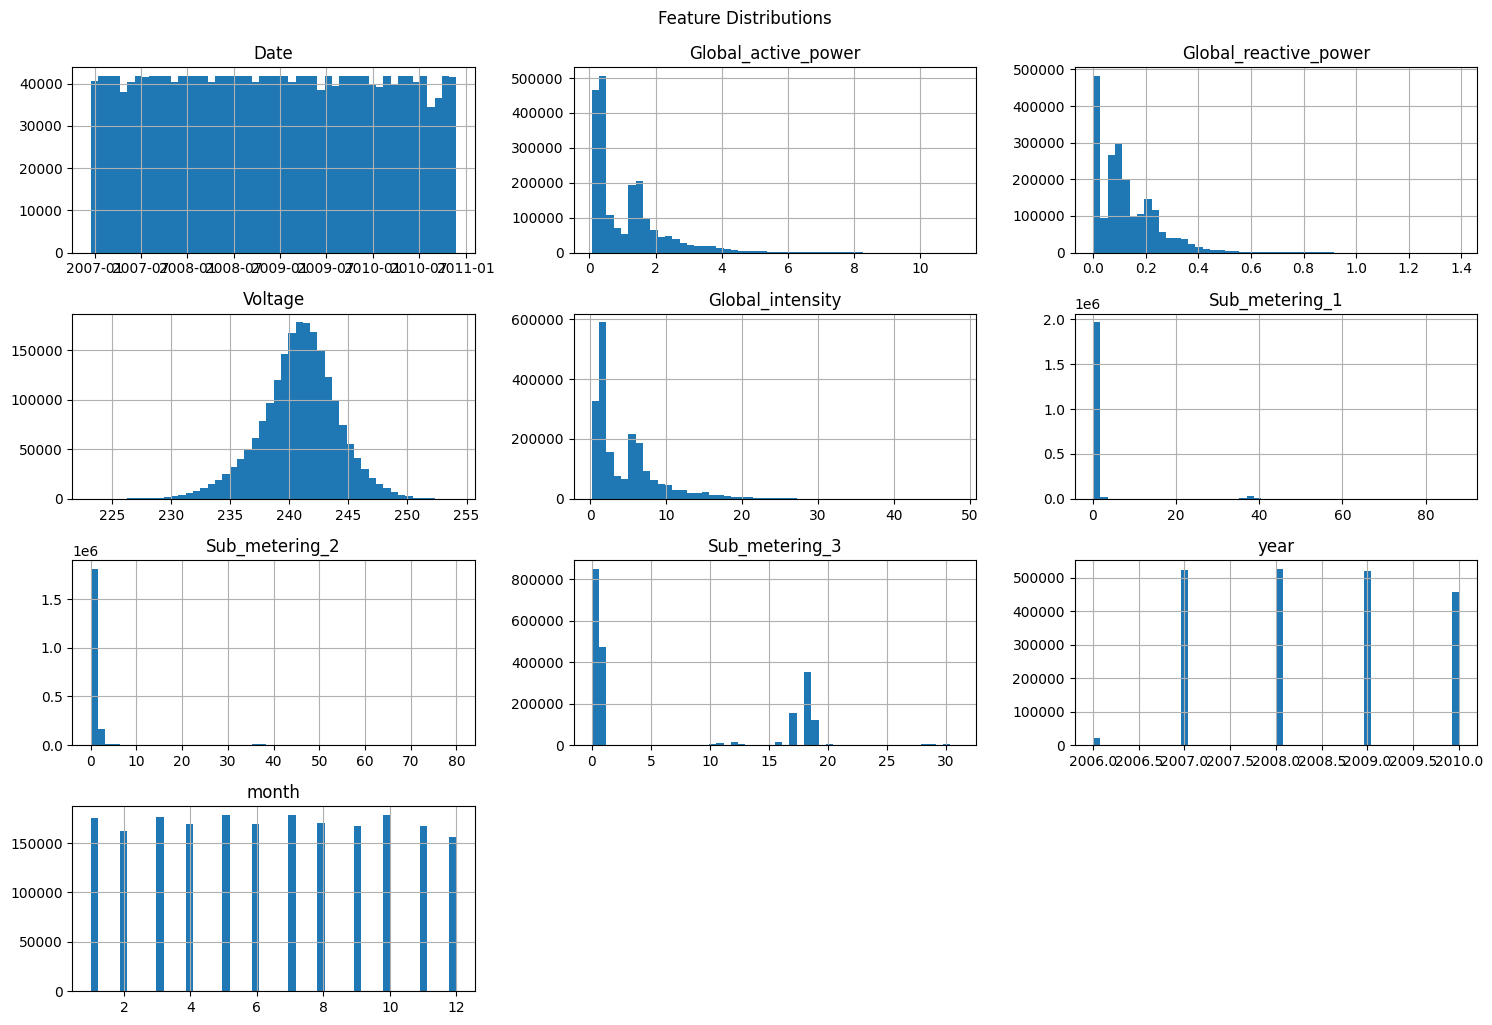

In [14]:
df.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.suptitle('Feature Distributions', y=1.02)
plt.show()


In [15]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'year', 'month', 'day', 'only_time'],
      dtype='object')

In [16]:
df.drop(columns=['year', 'month', 'day', 'only_time'], inplace=True)



<Figure size 1500x800 with 0 Axes>

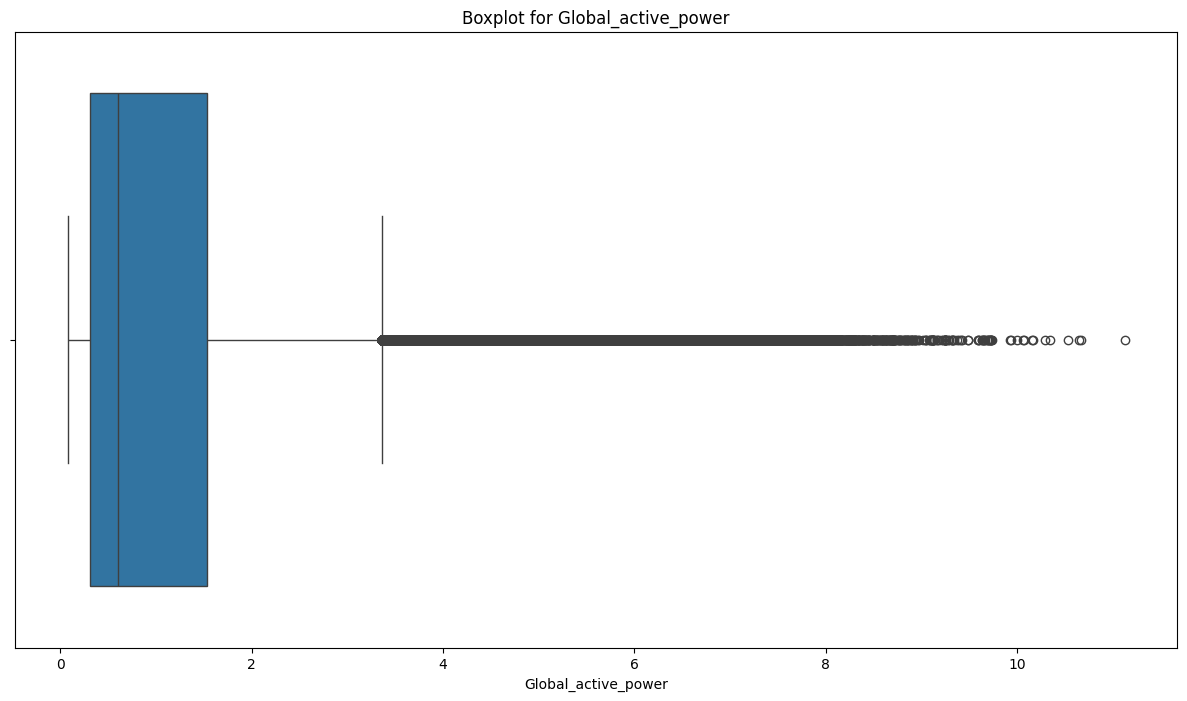

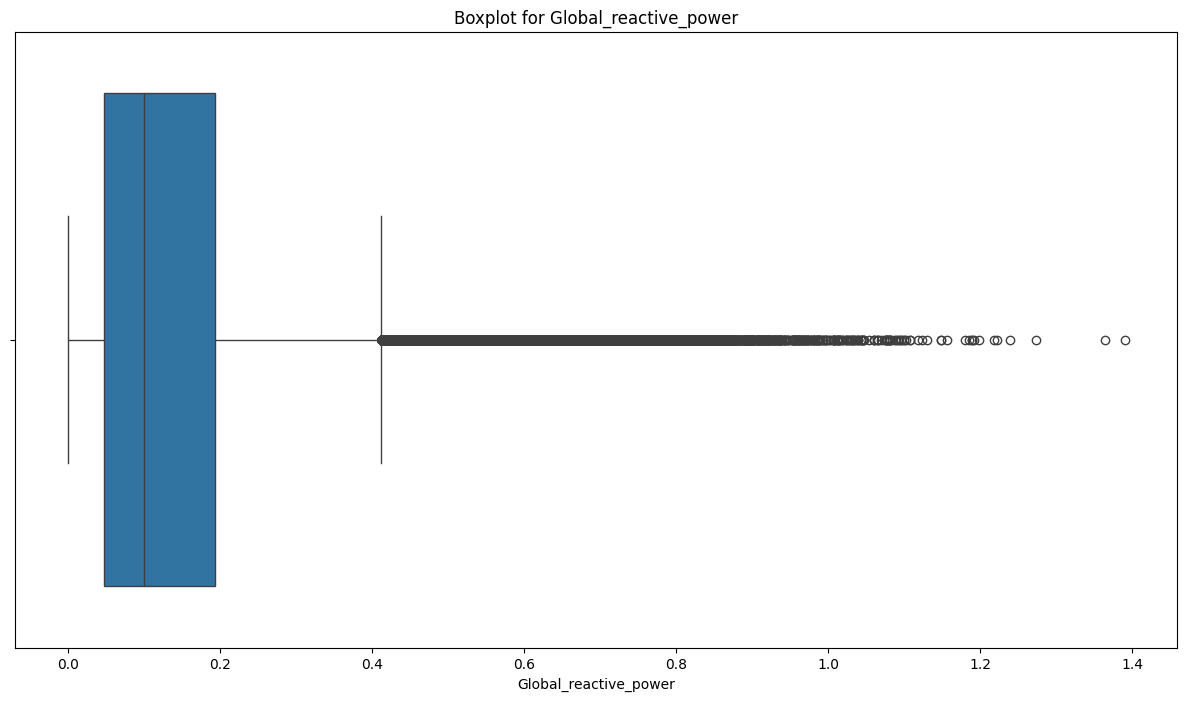

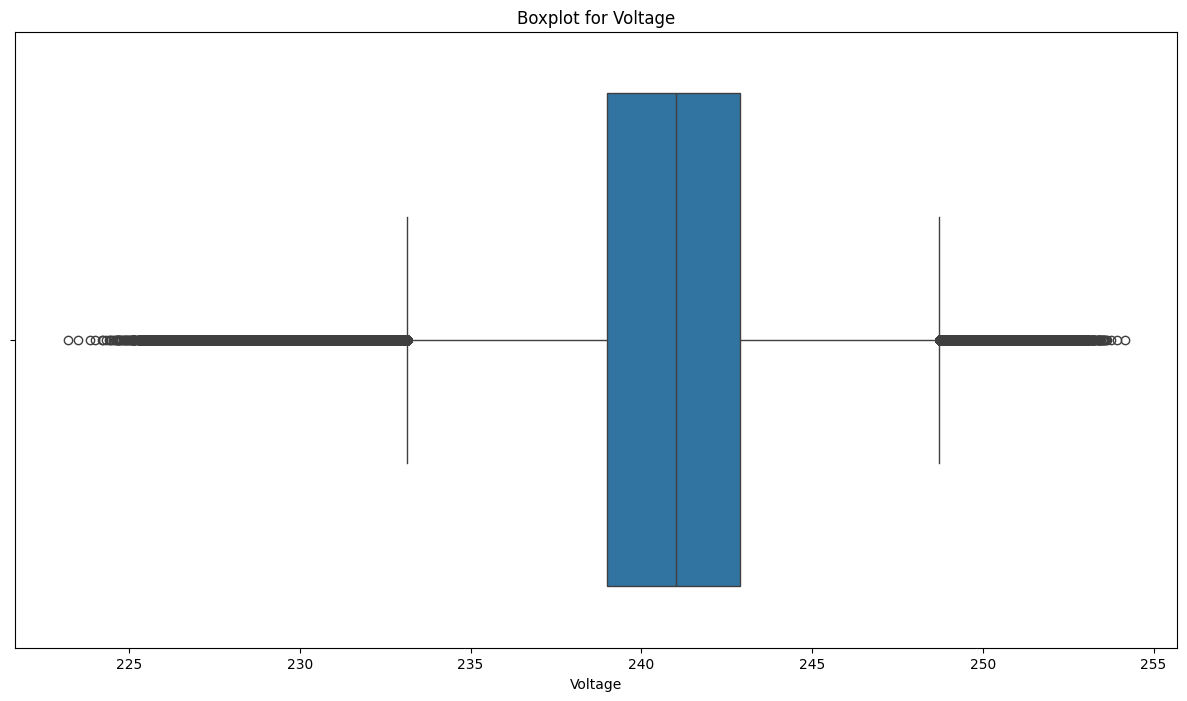

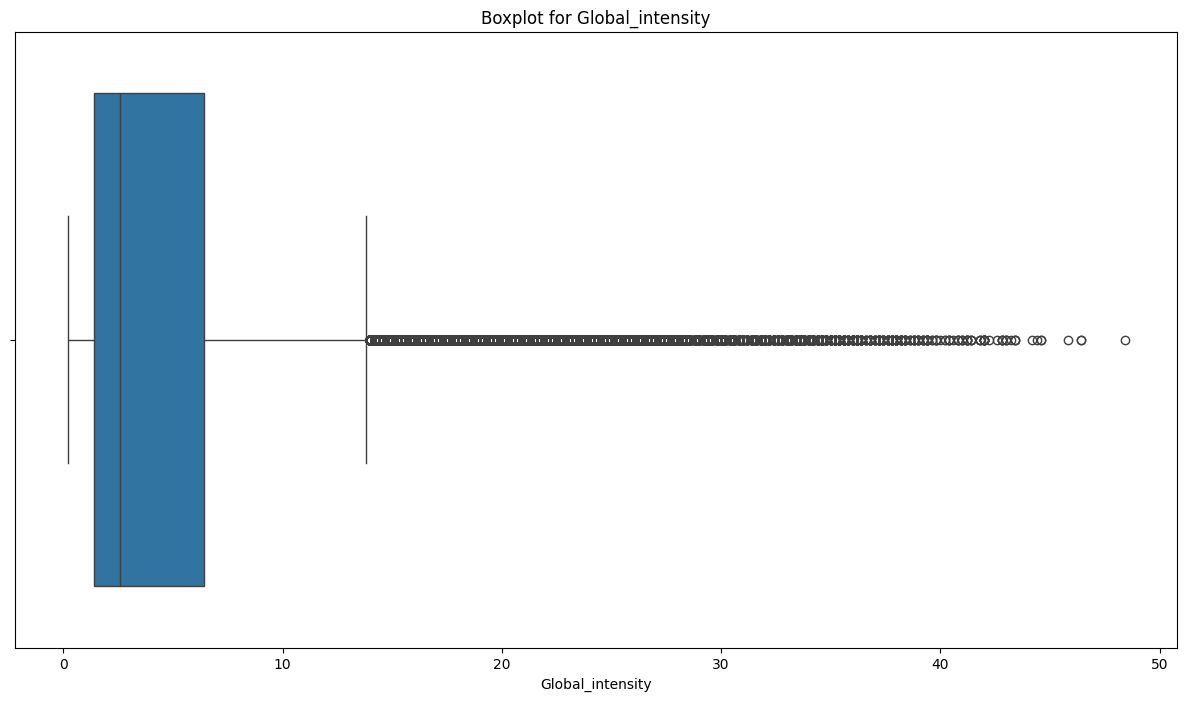

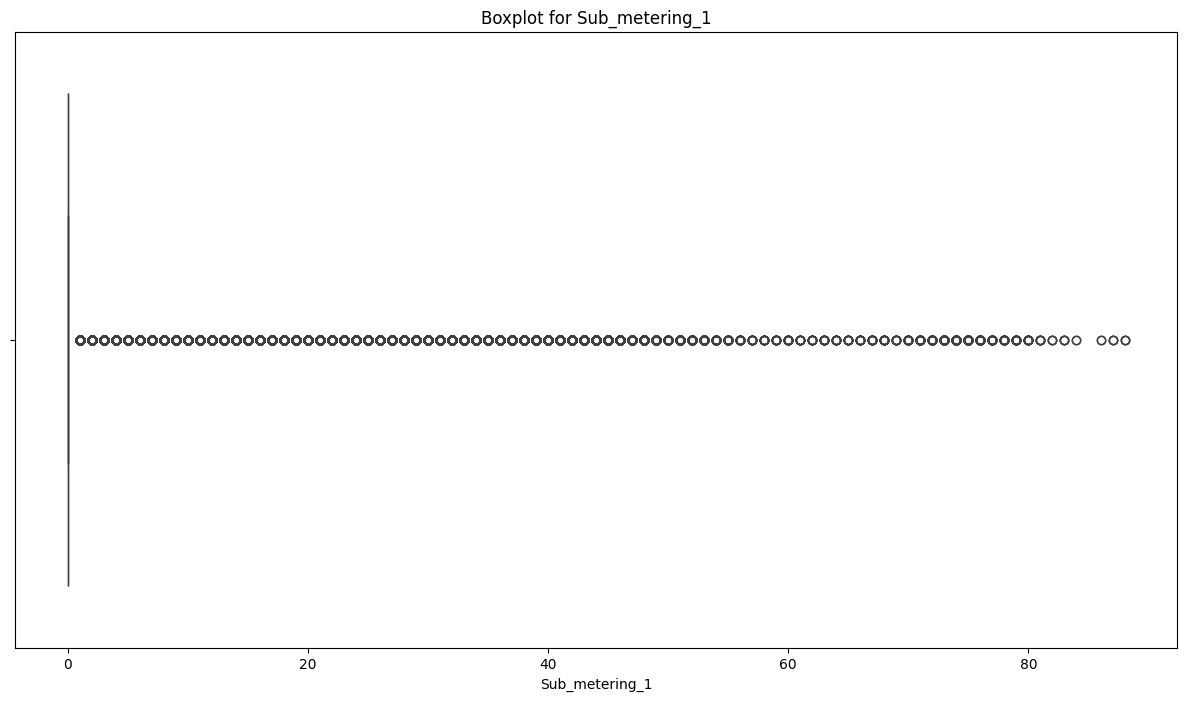

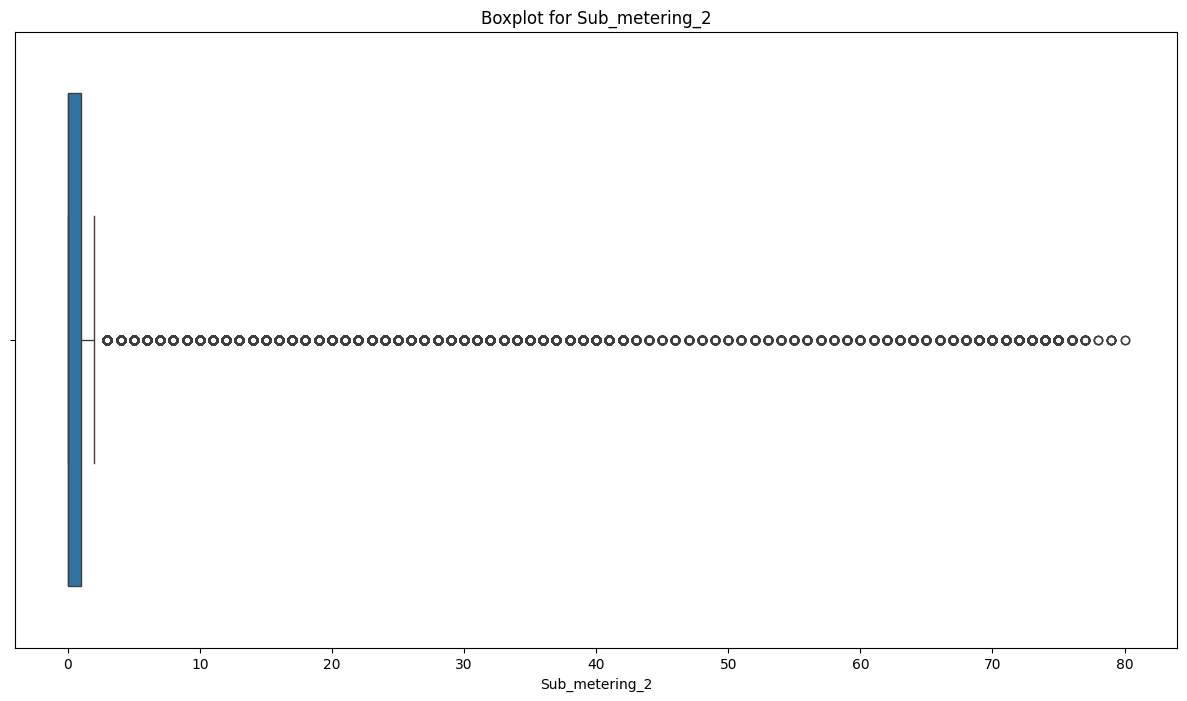

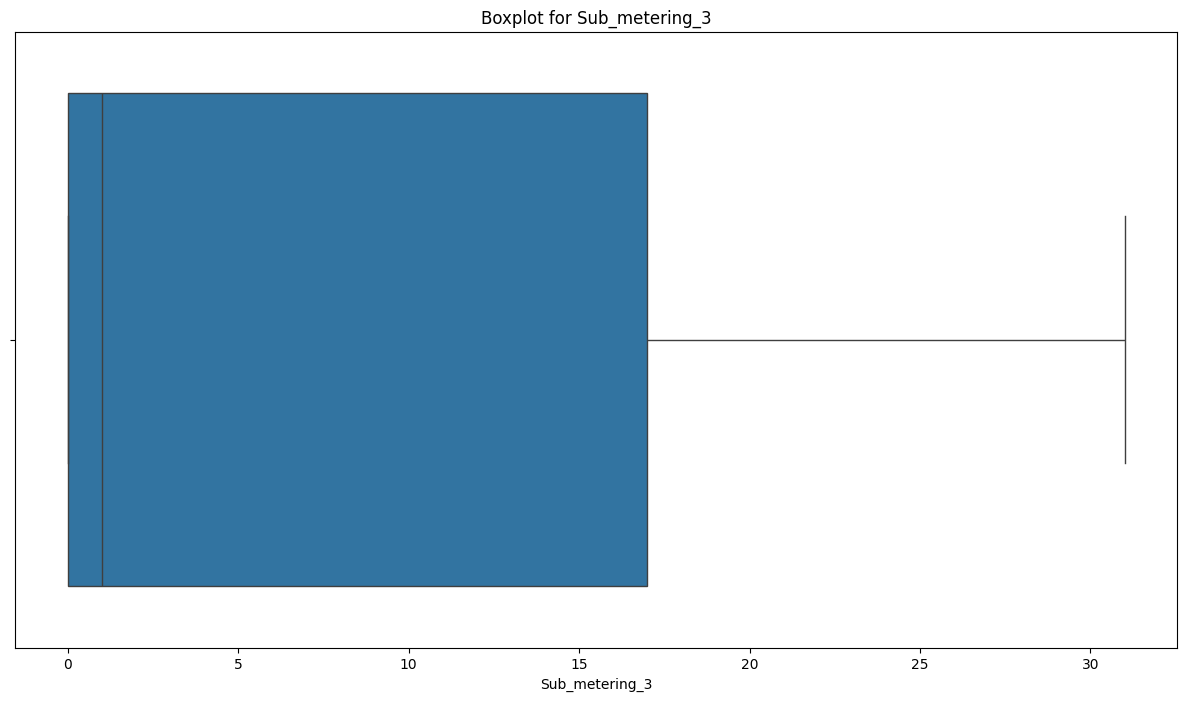

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 8))
for column in numeric_df.columns:
    plt.figure(figsize=(15, 8))
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot for {column}')
    plt.show()

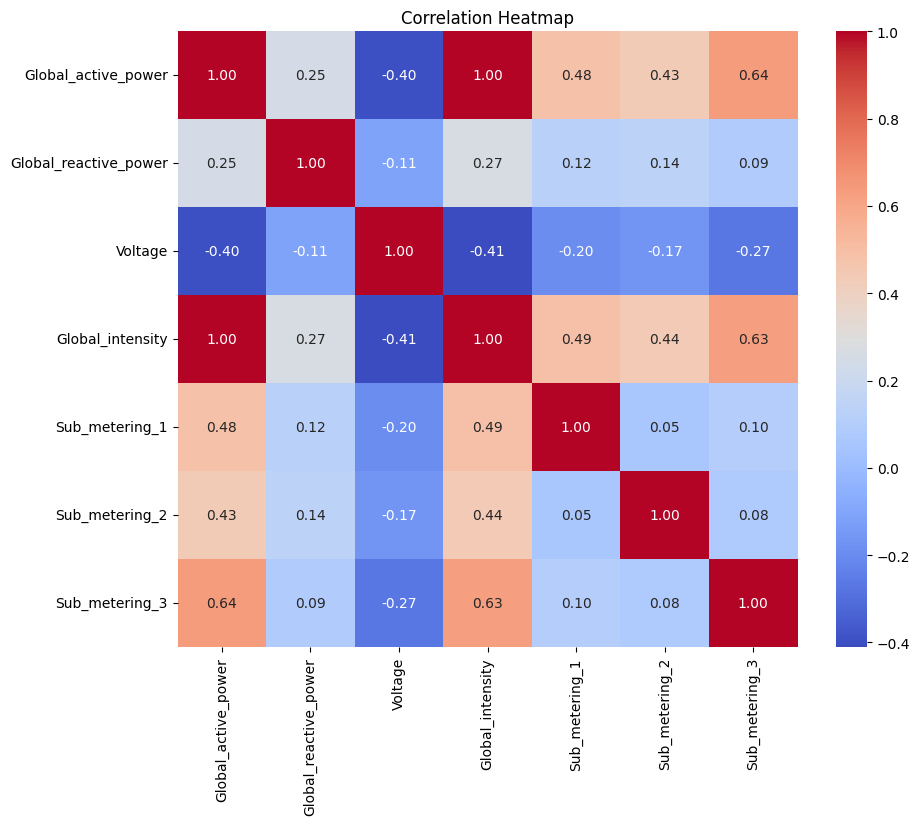

In [ ]:
numeric_columns = df.select_dtypes(include=[np.number])
corr = numeric_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()



In [24]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Year', 'Month', 'Hour'],
      dtype='object')

Peak Hours per Year:
     Year  Hour  Global_active_power
20   2006    20             2.857775
45   2007    21             2.049526
68   2008    20             1.916316
92   2009    20             1.898954
116  2010    20             1.700985

Peak Hours per Month:
     Month  Hour  Global_active_power
20       1    20             2.656492
44       2    20             2.289064
68       3    20             2.337649
93       4    21             1.934995
117      5    21             1.936649
141      6    21             1.568926
166      7    22             1.165185
189      8    21             0.786184
213      9    21             2.188740
236     10    20             2.171665
260     11    20             2.472373
284     12    20             2.522502


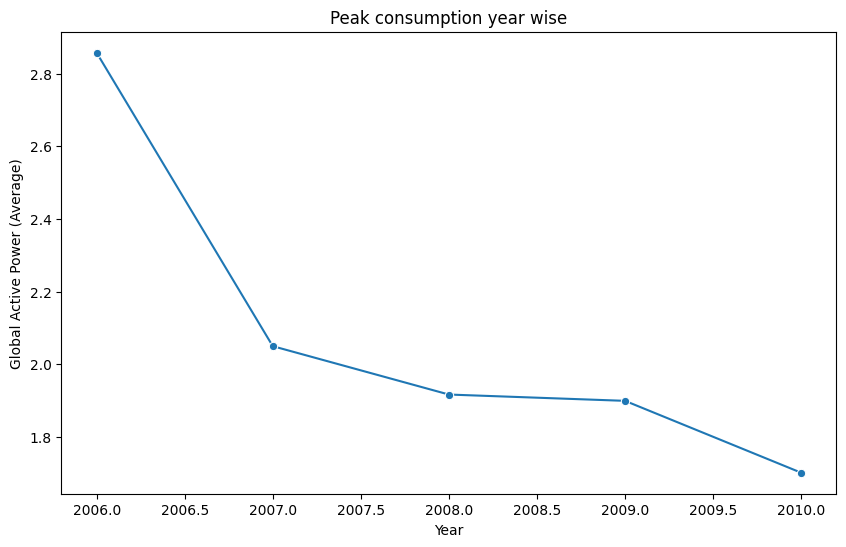

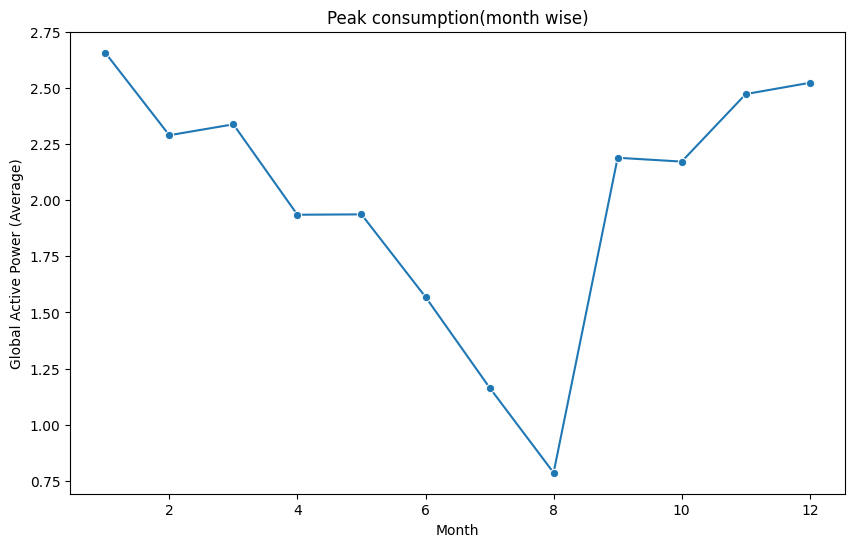

In [26]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')
df['Hour'] = df['Time'].dt.hour

# Group by Year and Hour to find peak hours per year
peak_hours_year = df.groupby(['Year', 'Hour'])['Global_active_power'].mean().reset_index()
peak_hours_year = peak_hours_year.loc[peak_hours_year.groupby('Year')['Global_active_power'].idxmax()]

# Group by Month and Hour to find peak hours per month
peak_hours_month = df.groupby(['Month', 'Hour'])['Global_active_power'].mean().reset_index()
peak_hours_month = peak_hours_month.loc[peak_hours_month.groupby('Month')['Global_active_power'].idxmax()]

# Print the peak hours for each
print("Peak Hours per Year:")
print(peak_hours_year)

print("\nPeak Hours per Month:")
print(peak_hours_month)

# Visualize Peak Hours per Year and Month

# Plot for Peak Hours per Year
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Global_active_power', data=peak_hours_year, marker='o')
plt.title('Peak consumption year wise')
plt.xlabel('Year')
plt.ylabel('Global Active Power (Average)')
plt.show()

# Plot for Peak Hours per Month
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Global_active_power', data=peak_hours_month, marker='o')
plt.title('Peak consumption(month wise)')
plt.xlabel('Month')
plt.ylabel('Global Active Power (Average)')
plt.show()


In [29]:
def detect_outliers(df, column):
    # Calculate the IQR (Interquartile Range)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the upper and lower bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    # Calculate the percentage of outliers
    outlier_percentage = len(outliers) / len(df) * 100
    
    return outliers, outlier_percentage

# Loop through all columns (except 'Date' and 'Time') to calculate outliers
outliers_data = {}
for column in df.columns:
    if column not in ['Date', 'Time', 'Datetime', 'Year', 'Month', 'Hour']:
        outliers, outlier_percentage = detect_outliers(df, column)
        outliers_data[column] = {'Outliers': outliers, 'Percentage': outlier_percentage}

# Print outliers data for each column
for column, data in outliers_data.items():
    print(f"Outlier Percentage for {column}: {round(data['Percentage'],2)}%")

Outlier Percentage for Global_active_power: 4.63%
Outlier Percentage for Global_reactive_power: 1.97%
Outlier Percentage for Voltage: 2.49%
Outlier Percentage for Global_intensity: 4.93%
Outlier Percentage for Sub_metering_1: 8.25%
Outlier Percentage for Sub_metering_2: 3.76%
Outlier Percentage for Sub_metering_3: 0.0%


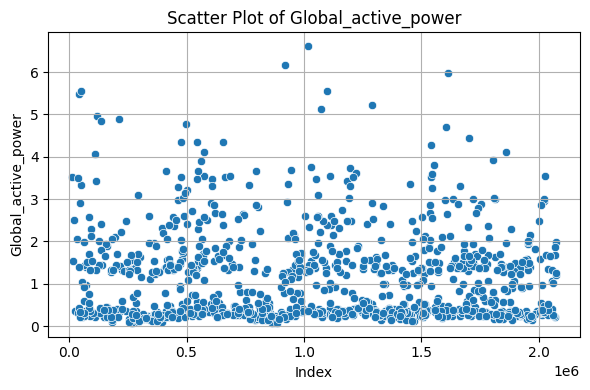

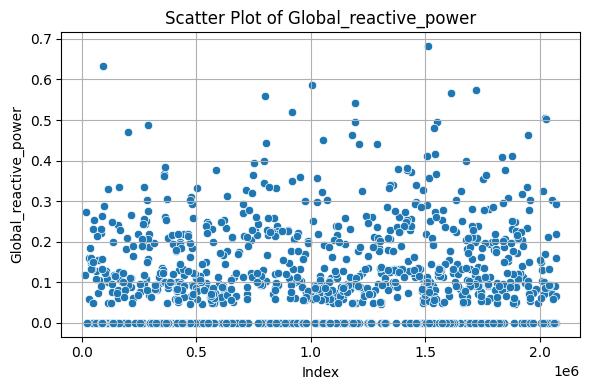

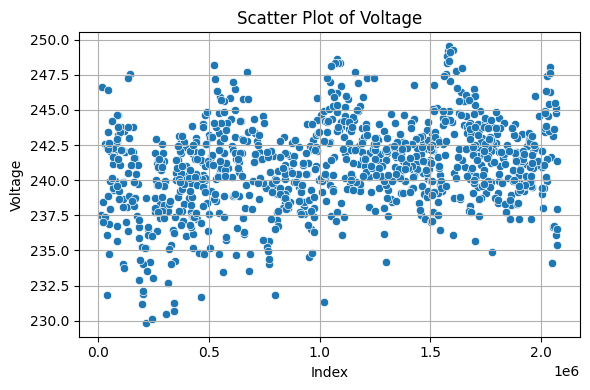

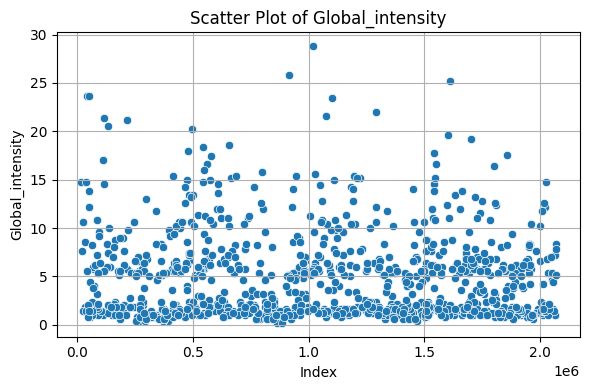

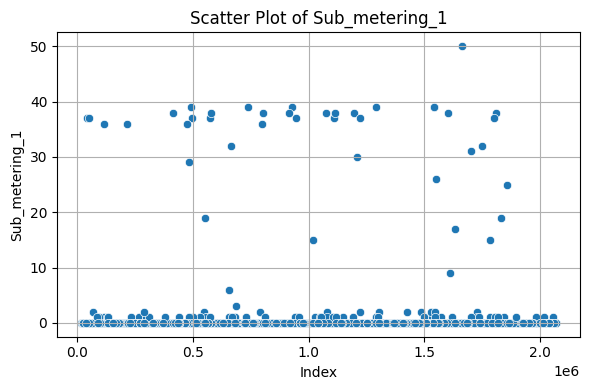

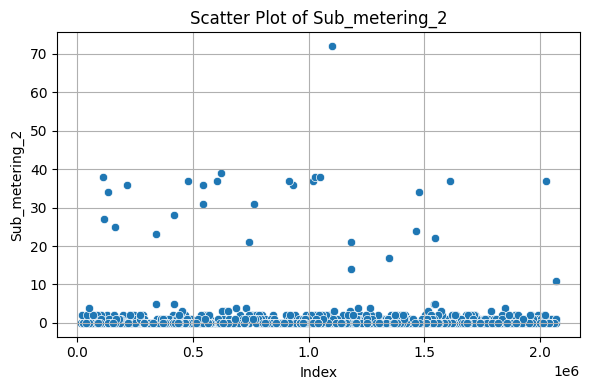

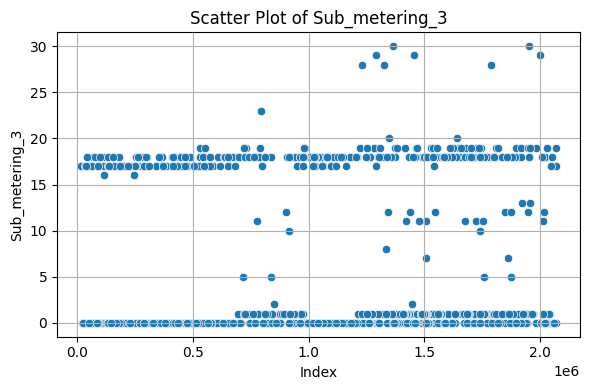

In [ ]:
sample_df = df.sample(1000)

# Loop through numeric columns
for col in sample_df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=sample_df.index, y=sample_df[col])
    plt.title(f'Scatter Plot of {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [30]:
df.to_csv(r"C:\prj_power_consumption\Cleaned_data_eda.csv",index = False)